# 🛸 AeroInspect — 건물 하자 탐지 AI 학습 노트북

**프로젝트**: AeroInspect (드론 기반 자율 하자 점검 플랫폼) — 2차 프로젝트

**이 노트북에서 학습하는 모델 (우선순위순)**:

1. 🔥 **YOLOv8 열화상 균열+습기 탐지** (Crack, Moisture) — 프로젝트 핵심 (B-01, B-02, B-04)
2. 🔥 **YOLOv8 열화상 박리 탐지** (delamination) — 단열 결함 (B-02)
3. 🧱 **ResNet50 벽지 하자 분류** (18 클래스) — 마감 하자 (C-01~C-05)

**환경**: Colab 무료 T4 GPU + Ultralytics YOLOv8n/s + PyTorch torchvision

---

## 📋 사용 순서
1. **Section 0**: GPU 확인 + 라이브러리 설치
2. **Section 1**: 데이터 업로드 (Google Drive 마운트 또는 zip 직접 업로드)
3. **Section 2~4**: 모델 학습 (원하는 모델만 골라서 실행 가능)
4. **Section 5**: 학습된 모델로 새 이미지에서 하자 탐지 (추론)

---
## Section 0 — 환경 준비

**❗ Colab 런타임 설정**: 메뉴 → 런타임 → 런타임 유형 변경 → 하드웨어 가속기 **T4 GPU** 선택

In [ ]:
# GPU 확인
!nvidia-smi

Fri Apr 17 08:35:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# 필요 라이브러리 설치 (최신 ultralytics가 numpy 2.x 호환)
!pip install -q -U ultralytics

import torch
import ultralytics
from ultralytics import YOLO
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"Ultralytics: {ultralytics.__version__}")

PyTorch: 2.5.1+cu121
CUDA available: True
GPU: Tesla T4
Ultralytics: 8.4.38


---
## Section 1 — 데이터 준비

두 가지 방법 중 **하나만** 실행하세요.

### 방법 A — Google Drive 마운트 (추천)
1. 로컬에서 `pjdron 파일들` 폴더를 Google Drive의 `MyDrive/AeroInspect/datasets/` 경로로 통째로 업로드
2. 아래 셀 실행 → Drive 인증 → 자동으로 경로 잡힘

### 방법 B — 직접 zip 업로드
1. 로컬에서 각 데이터셋 폴더를 zip으로 압축
2. 아래 "방법 B" 셀 실행 → 파일 선택 → 자동 압축 해제

In [ ]:
# === 방법 A: Google Drive 마운트 ===
from google.colab import drive
drive.mount('/content/drive')

# Drive에서 데이터셋 루트 경로 (업로드한 위치에 맞게 수정)
import os
DATA_ROOT = '/content/drive/MyDrive/드론/새 폴더'

# 각 데이터셋 경로 (README_데이터셋정리.txt 기준)
THERMAL_CRACK_MOISTURE = f'{DATA_ROOT}/열화상/Thermal_Imaging_in_Building_v1'
THERMAL_DELAMINATION   = f'{DATA_ROOT}/열화상/Building_Thermal_Inspection_v11'
WALLPAPER_CLASSIFY     = f'{DATA_ROOT}/하자 관련/Wallpaper_v2_Folder_Classification'

# 경로 확인
for name, p in [('Thermal_Crack_Moisture', THERMAL_CRACK_MOISTURE),
                ('Thermal_Delamination', THERMAL_DELAMINATION),
                ('Wallpaper_Classify', WALLPAPER_CLASSIFY)]:
    exists = '✅' if os.path.exists(p) else '❌'
    print(f'{exists} {name}: {p}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Thermal_Crack_Moisture: /content/drive/MyDrive/드론/새 폴더/열화상/Thermal_Imaging_in_Building_v1
✅ Thermal_Delamination: /content/drive/MyDrive/드론/새 폴더/열화상/Building_Thermal_Inspection_v11
✅ Wallpaper_Classify: /content/drive/MyDrive/드론/새 폴더/하자 관련/Wallpaper_v2_Folder_Classification


In [ ]:
# === 방법 B: 직접 zip 업로드 (Drive 안 쓸 때만 실행) ===
# from google.colab import files
# import zipfile, os
#
# os.makedirs('/content/datasets', exist_ok=True)
# print('열화상(Crack+Moisture), 열화상(Delamination), 벽지분류 zip 파일을 각각 업로드하세요.')
# uploaded = files.upload()
#
# for fname in uploaded.keys():
#     with zipfile.ZipFile(fname, 'r') as z:
#         z.extractall('/content/datasets/')
#     print(f'✅ {fname} 압축 해제 완료')
#
# # 압축 해제 후 실제 폴더명에 맞게 아래 변수 수정하세요
# # THERMAL_CRACK_MOISTURE = '/content/datasets/Thermal_Imaging_in_Building_v1'
# # THERMAL_DELAMINATION   = '/content/datasets/Building_Thermal_Inspection_v11'
# # WALLPAPER_CLASSIFY     = '/content/datasets/Wallpaper_v2_Folder_Classification'

In [ ]:
# YOLO data.yaml의 상대경로가 Colab 환경에 맞도록 절대경로로 재작성
# (원본 data.yaml은 ../train/images 같은 상대경로라 학습 시 경로 틀어질 수 있음)
import yaml, os

def fix_yolo_yaml(dataset_dir, names, nc):
    yaml_path = os.path.join(dataset_dir, 'data.yaml')
    fixed = {
        'path': dataset_dir,
        'train': 'train/images',
        'val':   'valid/images',
        'test':  'test/images',
        'nc':    nc,
        'names': names,
    }
    with open(yaml_path, 'w') as f:
        yaml.safe_dump(fixed, f, allow_unicode=True, sort_keys=False)
    print(f'✅ {yaml_path} 재작성 완료')
    return yaml_path

YAML_CRACK_MOISTURE = fix_yolo_yaml(THERMAL_CRACK_MOISTURE, ['Crack', 'Moisture'], 2)
YAML_DELAMINATION   = fix_yolo_yaml(THERMAL_DELAMINATION,   ['delamination'], 1)

✅ /content/drive/MyDrive/드론/새 폴더/열화상/Thermal_Imaging_in_Building_v1/data.yaml 재작성 완료
✅ /content/drive/MyDrive/드론/새 폴더/열화상/Building_Thermal_Inspection_v11/data.yaml 재작성 완료


---
## Section 2 — 🔥 YOLOv8 열화상 균열 + 습기 탐지 학습

- **데이터셋**: Thermal_Imaging_in_Building_v1 (615장, 2 클래스)
- **모델**: YOLOv8s (T4 GPU에 적정)
- **용도**: 드론 열화상 영상에서 균열(Crack)과 습기(Moisture) 동시 탐지
- **예상 시간**: T4 기준 약 20~30분 (100 epochs)

In [ ]:
import torch
if not torch.__version__.startswith("2.5.1+cu121"):
    print(f"현재: {torch.__version__} → CUDA 12.1용으로 교체 중... (2~3분)")
    !pip uninstall -y -q torch torchvision torchaudio
    !pip install -q torch==2.5.1 torchvision==0.20.1 --index-url https://download.pytorch.org/whl/cu121
    !pip install -q "ultralytics>=8.3.0"
    print("\n✅ 설치 완료! 자동 재시작합니다 (연결 끊김 메시지 뜨면 정상)")
    import os, time; time.sleep(2)
    os.kill(os.getpid(), 9)
else:
    from ultralytics import YOLO
    import ultralytics
    print(f"✅ PyTorch: {torch.__version__}")
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ Ultralytics: {ultralytics.__version__}")

✅ PyTorch: 2.5.1+cu121
✅ GPU: Tesla T4
✅ Ultralytics: 8.4.38


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')  # pretrained COCO weights

results = model.train(
    data=YAML_CRACK_MOISTURE,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,               # early stopping
    project='/content/runs_thermal_crack_moisture',
    name='yolov8s_100ep',
    device=0,
    optimizer='AdamW',
    lr0=0.001,
    cos_lr=True,
    augment=True,              # Mosaic, MixUp 등
    # 열화상 특화: 색상 증강 약화 (열화상은 색 분포가 중요)
    hsv_h=0.0,
    hsv_s=0.3,
    hsv_v=0.3,
    save=True,
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/드론/새 폴더/열화상/Thermal_Imaging_in_Building_v1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.3, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_100ep, nbs=64, nms=False, opset=None, optimize=False, 

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.4 ms, read: 23.9±11.4 MB/s, size: 37.3 KB)
val: Scanning /content/drive/MyDrive/드론/새 폴더/열화상/Thermal_Imaging_in_Building_v1/valid/labels.cache... 14 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14/14 4.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.6it/s 0.6s
                   all         14         28      0.649      0.529      0.575      0.256
              Moisture         14         28      0.649      0.529      0.575      0.256
Speed: 1.2ms preprocess, 14.5ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/detect/val

=== 최종 성능 (Crack + Moisture) ===
mAP@0.5:      0.5745
mAP@0.5:0.95: 0.2557
Precision:    0.6493
Recall:       0.5292


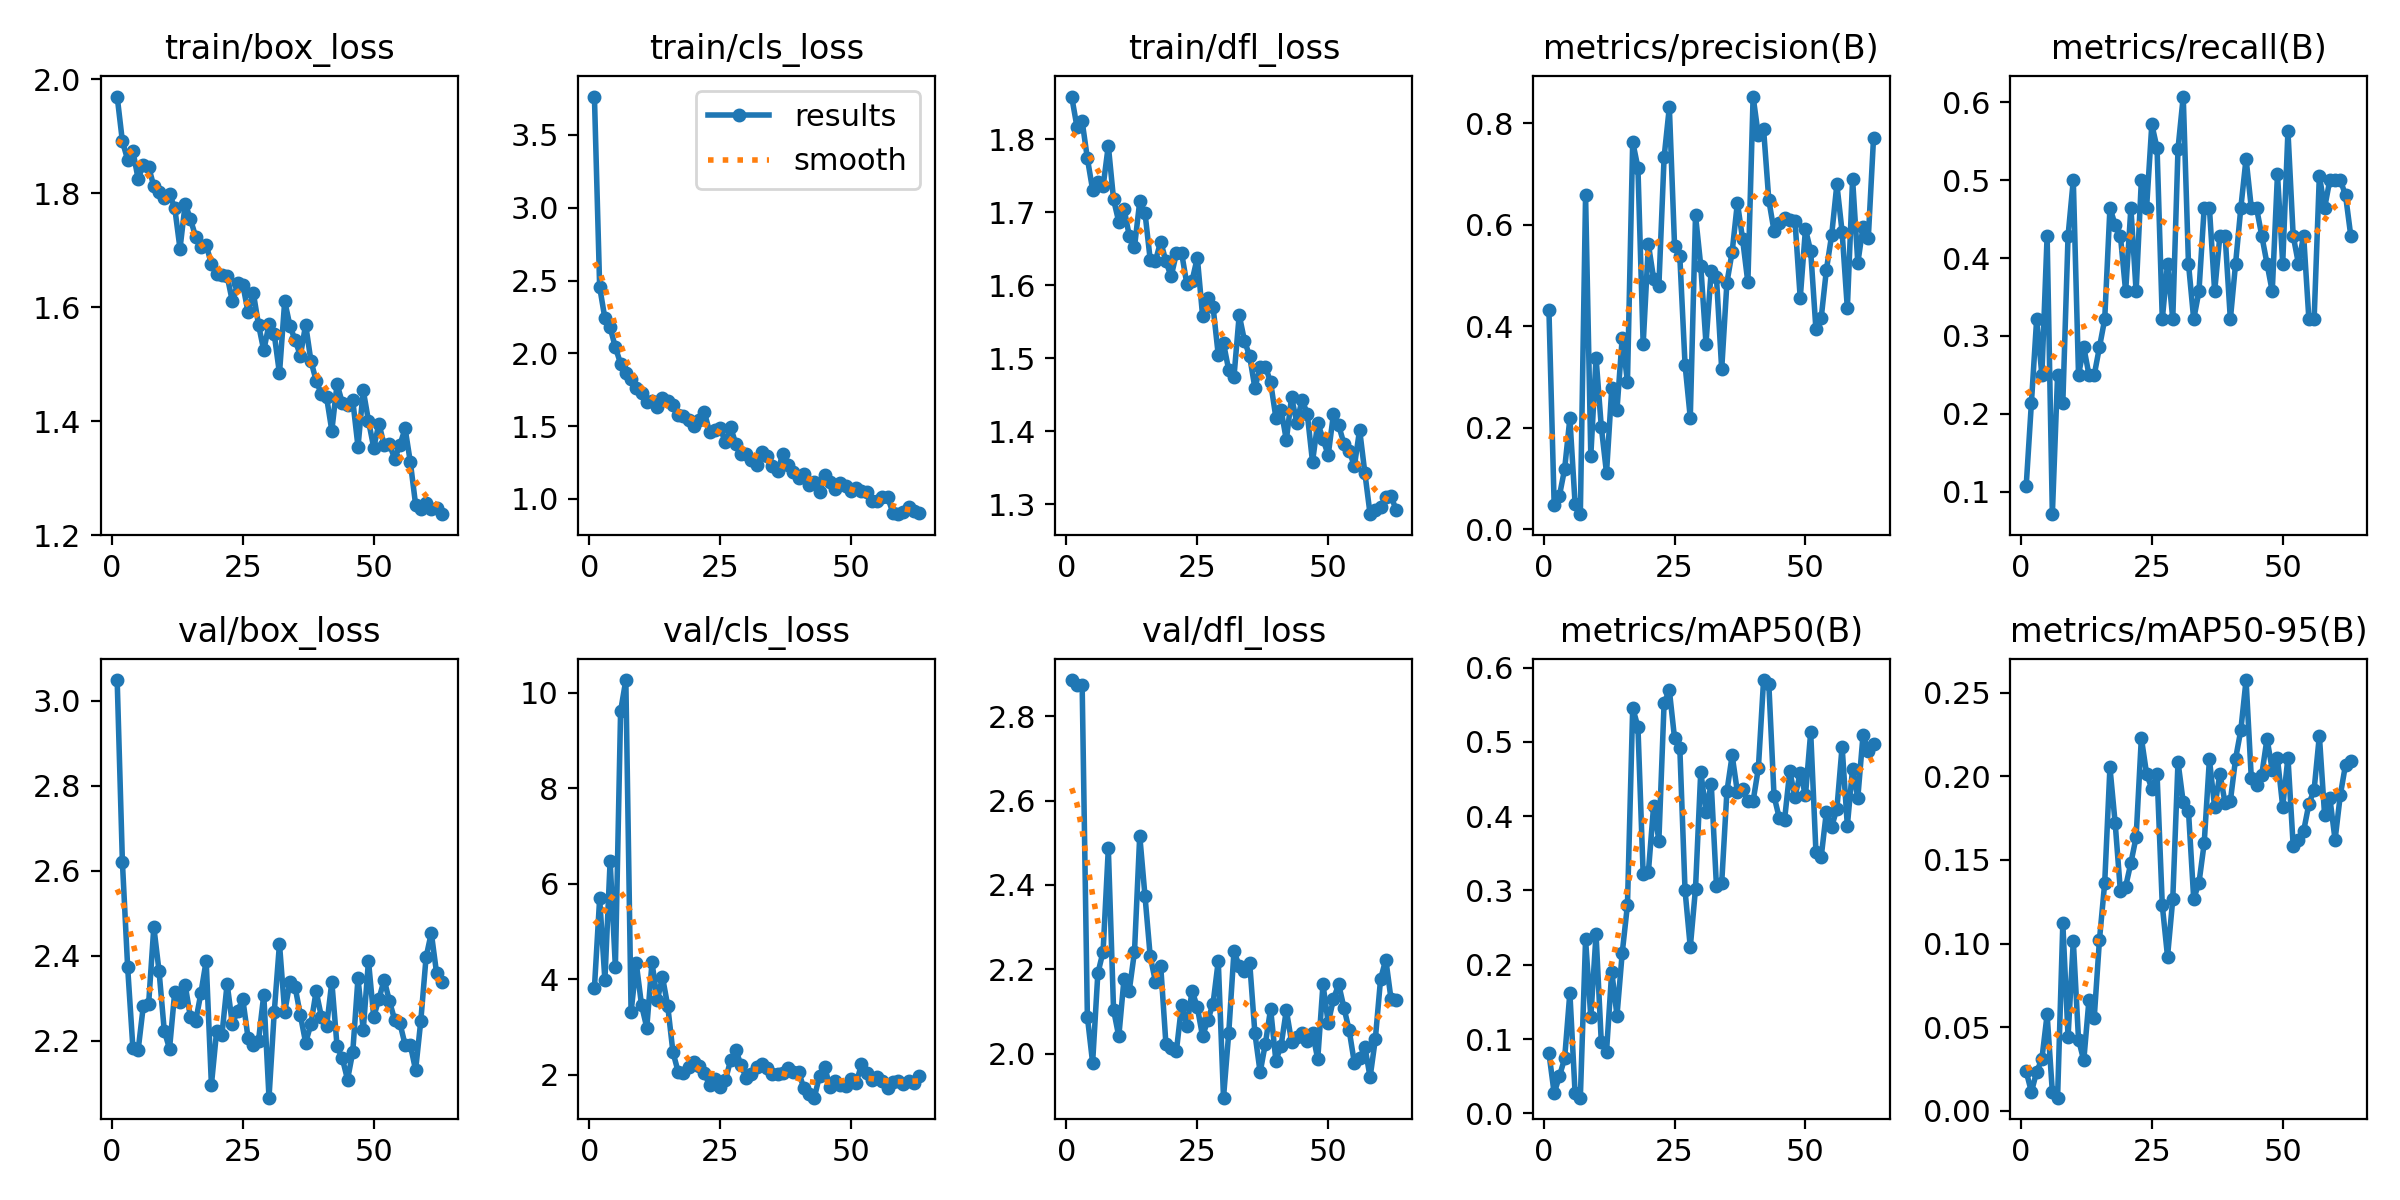

In [ ]:
# 검증 및 결과 확인
metrics = model.val()
print(f"\n=== 최종 성능 (Crack + Moisture) ===")
print(f"mAP@0.5:      {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision:    {metrics.box.mp:.4f}")
print(f"Recall:       {metrics.box.mr:.4f}")

# 학습 결과 그래프 확인
from IPython.display import Image
Image('/content/runs_thermal_crack_moisture/yolov8s_100ep/results.png')

In [ ]:
# best.pt를 Google Drive에 백업 (세션 끊겨도 보존)
import shutil, os
os.makedirs('/content/drive/MyDrive/드론/weights', exist_ok=True)

src = '/content/runs_thermal_crack_moisture/yolov8s_100ep/weights/best.pt'
dst = '/content/drive/MyDrive/드론/weights/yolov8s_crack_moisture_best.pt'
shutil.copy(src, dst)
print(f'✅ 가중치 저장: {dst}')

✅ 가중치 저장: /content/drive/MyDrive/드론/weights/yolov8s_crack_moisture_best.pt


---
## Section 3 — 🔥 YOLOv8 열화상 박리 (Delamination) 탐지 학습

- **데이터셋**: Building_Thermal_Inspection_v11 (403장, 1 클래스)
- **모델**: YOLOv8s
- **용도**: 외벽 박리(단열재 탈락) 탐지 — 프로젝트 B-02
- **예상 시간**: T4 기준 약 15~20분

In [ ]:
model_delam = YOLO('yolov8s.pt')

results_delam = model_delam.train(
    data=YAML_DELAMINATION,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    project='/content/runs_thermal_delamination',
    name='yolov8s_100ep',
    device=0,
    optimizer='AdamW',
    lr0=0.001,
    cos_lr=True,
    hsv_h=0.0,
    hsv_s=0.3,
    hsv_v=0.3,
    save=True,
)

# 성능 확인 + Drive 백업
metrics_delam = model_delam.val()
print(f"mAP@0.5: {metrics_delam.box.map50:.4f}, mAP@0.5:0.95: {metrics_delam.box.map:.4f}")

shutil.copy(
    '/content/runs_thermal_delamination/yolov8s_100ep/weights/best.pt',
    '/content/drive/MyDrive/드론/weights/yolov8s_delamination_best.pt'
)
print('✅ Delamination 가중치 저장 완료')

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/드론/새 폴더/열화상/Building_Thermal_Inspection_v11/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.3, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_100ep, nbs=64, nms=False, opset=None, optimize=False

---
## Section 4 — 🧱 ResNet50 벽지 하자 분류 학습 (18 클래스)

- **데이터셋**: Wallpaper_v2_Folder_Classification (3,462장, 18 클래스)
- **모델**: ImageNet pretrained ResNet50 → Transfer Learning
- **용도**: RGB 카메라 영상에서 벽지·마감 하자 유형 분류 (C-01~C-05)
- **예상 시간**: T4 기준 약 30분 (20 epochs)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import os, time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 데이터 증강
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(f'{WALLPAPER_CLASSIFY}/train', transform=train_tf)
val_ds   = datasets.ImageFolder(f'{WALLPAPER_CLASSIFY}/valid', transform=val_tf)
test_ds  = datasets.ImageFolder(f'{WALLPAPER_CLASSIFY}/test',  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f'클래스 수: {NUM_CLASSES}')
print(f'클래스: {CLASS_NAMES}')
print(f'train: {len(train_ds)}장 / valid: {len(val_ds)}장 / test: {len(test_ds)}장')

클래스 수: 19
클래스: ['Baseboard', 'Crying', 'Damage', 'Defective_Joint', 'Exploded', 'Furniture', 'Gypsum', 'Kink', 'Many_niches', 'Mold', 'Molding', 'Piece', 'Plane', 'Pollution', 'Rust', 'Spot', 'W.F_D.F', 'Wrong_punch', 'good']
train: 2384장 / valid: 679장 / test: 341장


In [ ]:
import shutil, os, time

# Drive → Colab 로컬로 복사 (3,462장이라 5분 정도)
print('📂 데이터 복사 시작...')
t0 = time.time()

src = '/content/drive/MyDrive/드론/새 폴더/하자 관련/Wallpaper_v2_Folder_Classification'
dst = '/content/wallpaper_local'

if not os.path.exists(dst):
    shutil.copytree(src, dst)
    print(f'✅ 복사 완료! {time.time()-t0:.0f}초')
else:
    print('이미 복사돼 있음')

# 경로 변수 교체 (이게 핵심!)
WALLPAPER_CLASSIFY = dst
print(f'새 경로: {WALLPAPER_CLASSIFY}')

📂 데이터 복사 시작...
✅ 복사 완료! 160초
새 경로: /content/wallpaper_local


In [ ]:
# ResNet50 Transfer Learning
model_cls = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model_cls.fc = nn.Linear(model_cls.fc.in_features, NUM_CLASSES)
model_cls = model_cls.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_cls.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

EPOCHS = 20
best_val_acc = 0.0

for epoch in range(EPOCHS):
    # --- Train ---
    model_cls.train()
    train_loss, train_correct, train_total = 0, 0, 0
    t0 = time.time()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model_cls(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total += imgs.size(0)
    scheduler.step()

    # --- Val ---
    model_cls.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_cls(imgs)
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += imgs.size(0)

    train_acc = train_correct / train_total
    val_acc   = val_correct / val_total
    print(f'Epoch {epoch+1:02d}/{EPOCHS} | train_loss={train_loss/train_total:.4f} '
          f'train_acc={train_acc:.4f} val_acc={val_acc:.4f} | {time.time()-t0:.1f}s')

    # best 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs('/content/drive/MyDrive/드론/weights', exist_ok=True)
        torch.save({
            'model_state_dict': model_cls.state_dict(),
            'class_names': CLASS_NAMES,
            'val_acc': val_acc,
        }, '/content/drive/MyDrive/드론/weights/resnet50_wallpaper_best.pt')

print(f'\n✅ 최고 Val 정확도: {best_val_acc:.4f}')

Epoch 01/20 | train_loss=1.8584 train_acc=0.4883 val_acc=0.5125 | 28.5s
Epoch 02/20 | train_loss=1.0185 train_acc=0.7022 val_acc=0.5228 | 29.0s
Epoch 03/20 | train_loss=0.7270 train_acc=0.7798 val_acc=0.4963 | 32.7s
Epoch 04/20 | train_loss=0.5475 train_acc=0.8326 val_acc=0.5155 | 30.7s
Epoch 05/20 | train_loss=0.4201 train_acc=0.8716 val_acc=0.5096 | 29.9s
Epoch 06/20 | train_loss=0.3389 train_acc=0.8914 val_acc=0.5302 | 30.3s
Epoch 07/20 | train_loss=0.2731 train_acc=0.9161 val_acc=0.5052 | 35.3s
Epoch 08/20 | train_loss=0.2017 train_acc=0.9413 val_acc=0.5405 | 30.8s
Epoch 09/20 | train_loss=0.1661 train_acc=0.9572 val_acc=0.4919 | 32.9s
Epoch 10/20 | train_loss=0.1332 train_acc=0.9597 val_acc=0.5331 | 31.5s
Epoch 11/20 | train_loss=0.1039 train_acc=0.9706 val_acc=0.5184 | 31.7s
Epoch 12/20 | train_loss=0.0796 train_acc=0.9811 val_acc=0.5302 | 32.7s
Epoch 13/20 | train_loss=0.0764 train_acc=0.9841 val_acc=0.5434 | 31.2s
Epoch 14/20 | train_loss=0.0657 train_acc=0.9841 val_acc=0.5272 

In [ ]:
# Test 셋 평가
model_cls.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model_cls(imgs)
        test_correct += (out.argmax(1) == labels).sum().item()
        test_total += imgs.size(0)
print(f'🧪 Test 정확도: {test_correct/test_total:.4f}')

🧪 Test 정확도: 0.5425


---
## Section 5 — 🔍 학습한 모델로 새 이미지에서 하자 탐지 (추론)

드론으로 새로 찍은 사진을 업로드해서 학습한 3개 모델로 동시에 하자를 검출합니다.

**출력물**:
- YOLO 바운딩 박스가 그려진 결과 이미지
- 탐지된 하자 유형/위치/신뢰도 JSON (FastAPI 연동용)

In [1]:
# 추론용 유틸리티 함수 (FastAPI 백엔드에 그대로 옮겨 쓸 수 있도록 함수화)
import torch, json
from ultralytics import YOLO
from torchvision import transforms, models
from PIL import Image

# === 가중치 경로 ===
W_CRACK_MOISTURE = '/content/drive/MyDrive/드론/weights/yolov8s_crack_moisture_best.pt'
W_DELAMINATION   = '/content/drive/MyDrive/드론/weights/yolov8s_delamination_best.pt'
W_WALLPAPER      = '/content/drive/MyDrive/드론/weights/resnet50_wallpaper_best.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- YOLO 모델 로드 ---
yolo_thermal = YOLO(W_CRACK_MOISTURE)
yolo_delam   = YOLO(W_DELAMINATION)

# --- ResNet 분류기 로드 ---
ckpt = torch.load(W_WALLPAPER, map_location=device)
resnet = models.resnet50(weights=None)
resnet.fc = torch.nn.Linear(resnet.fc.in_features, len(ckpt['class_names']))
resnet.load_state_dict(ckpt['model_state_dict'])
resnet = resnet.to(device).eval()
WALLPAPER_CLASSES = ckpt['class_names']
cls_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def detect_defects(image_path, conf_threshold=0.25):
    """
    이미지 한 장에 대해 3개 모델을 모두 돌려서 하자를 검출.
    반환: {
        'yolo_thermal':  [{class, conf, bbox_xyxy}, ...],
        'yolo_delam':    [{class, conf, bbox_xyxy}, ...],
        'wallpaper_cls': {top1_class, top1_conf, top3}
    }
    FastAPI 백엔드 에서 그대로 JSONResponse로 반환 가능.
    """
    result = {'yolo_thermal': [], 'yolo_delam': [], 'wallpaper_cls': None}

    # --- YOLO 열화상 (Crack + Moisture) ---
    r = yolo_thermal(image_path, conf=conf_threshold, verbose=False)[0]
    for b in r.boxes:
        result['yolo_thermal'].append({
            'class': r.names[int(b.cls)],
            'conf':  float(b.conf),
            'bbox_xyxy': [float(x) for x in b.xyxy[0].tolist()],
        })

    # --- YOLO 박리 ---
    r = yolo_delam(image_path, conf=conf_threshold, verbose=False)[0]
    for b in r.boxes:
        result['yolo_delam'].append({
            'class': r.names[int(b.cls)],
            'conf':  float(b.conf),
            'bbox_xyxy': [float(x) for x in b.xyxy[0].tolist()],
        })

    # --- ResNet 밯지 하자 분류 ---
    img = Image.open(image_path).convert('RGB')
    x = cls_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = resnet(x)
        probs = torch.softmax(logits, dim=1)[0]
        top3 = torch.topk(probs, 3)
    result['wallpaper_cls'] = {
        'top1_class': WALLPAPER_CLASSES[top3.indices[0].item()],
        'top1_conf':  float(top3.values[0]),
        'top3': [
            {'class': WALLPAPER_CLASSES[top3.indices[i].item()], 'conf': float(top3.values[i])}
            for i in range(3)
        ],
    }
    return result

print('✅ 추론 함수 detect_defects() 정의 완료')

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
# 실제로 새 드론사진 올려서 테스트
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

print('드론으로 찍은 테스트 사진을 업로드하세요 (여러 장 가능)')
uploaded = files.upload()

for fname in uploaded.keys():
    print(f'\n{"="*60}\n📷 {fname}\n{"="*60}')
    result = detect_defects(fname, conf_threshold=0.25)
    print(json.dumps(result, indent=2, ensure_ascii=False))

    # 시각화: YOLO 결과 + 원본 이미지
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 원본
    axes[0].imshow(Image.open(fname))
    axes[0].set_title('원본')
    axes[0].axis('off')

    # YOLO thermal 결과 (바운딩 박스 그린 이미지)
    r1 = yolo_thermal(fname, conf=0.25, verbose=False)[0]
    axes[1].imshow(r1.plot()[..., ::-1])  # BGR -> RGB
    axes[1].set_title(f'열화상 Crack+Moisture ({len(r1.boxes)}개 탐지)')
    axes[1].axis('off')

    # YOLO delamination 결과
    r2 = yolo_delam(fname, conf=0.25, verbose=False)[0]
    axes[2].imshow(r2.plot()[..., ::-1])
    axes[2].set_title(f'박리 Delamination ({len(r2.boxes)}개 탐지)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    wp = result['wallpaper_cls']
    print(f"🎨 벽지 하자 예측: {wp['top1_class']} ({wp['top1_conf']:.3f})")
    print(f"   Top-3: " + ', '.join(f"{t['class']}({t['conf']:.2f})" for t in wp['top3']))

드론으로 찍은 테스트 사진을 업로드하세요 (여러 장 가능)


KeyboardInterrupt: 

---
## ✅ 다음 단계 체크리스트

학습 후 `MyDrive/AeroInspect/weights/`에 다음 파일이 생겼는지 확인:
- [ ] `yolov8s_crack_moisture_best.pt`
- [ ] `yolov8s_delamination_best.pt`
- [ ] `resnet50_wallpaper_best.pt`

**FastAPI 백엔드 연동 (2차 프로젝트 Phase 2)**:
- Section 5의 `detect_defects()` 함수를 그대로 백엔드 inference 엔드포인트에 옮겨쓰기
- 입력: multipart 이미지 / 출력: 위에 정의한 JSON 스키마
- WebSocket으로 드론 스트림 프레임마다 호출 → 탐지 결과 React 대시보드에 Push

**성능이 부족하면 시도할 것**:
1. epochs를 150~200으로 증가
2. YOLOv8m 사용 (T4로 가능, 배치 사이즈는 8로 축소)
3. 데이터 증강 강도 조정 (`degrees`, `translate`, `scale` 파라미터)
4. 열화상 전용 데이터 추가 수집 (특히 B-04 방수층 들뜸은 데이터 부족)